=========================================================
LINEAR PROGRAMMING USING SIMPLEX (SCIPY)
OLD vs NEW METHODS
=========================================================

This notebook demonstrates how to solve a Linear
Programming (LP) problem using:

1) OLD SIMPLEX METHOD  (method="simplex")
2) NEW HiGHS SOLVER   (method="highs")

The problem is written PURELY in mathematical form:
- Objective function
- Constraints
- Decision variables



=========================================================
MATHEMATICAL FORMULATION
=========================================================

Decision Variables:
x1, x2, x3, x4, x5, x6 ≥ 0

Objective Function (Minimize):
Z= 4x1 + 6x2 + 9x3 + 5x4 + 4x5 + 7x6

Subject to (Constraints):

Inequality constraints:
x1 - 2x2 + x3 ≤ 40,
4x4 + x5 + x6 ≤ 30,
x1 - 8x4 ≤ 30,
2x2 + x5 ≤ 20,
-x3 + 9x6 ≤ 10,
x1 + x2 + x3 ≥ 15.

=========================================================
IMPORTANT NOTE ON SOLVERS
=========================================================

OLD SIMPLEX:
- Classical simplex algorithm
- Deprecated in SciPy
- Slower and less stable

NEW HiGHS:
- Modern LP solver
- Faster and more reliable
- Uses advanced simplex / interior-point methods
- RECOMMENDED


CPLEX:
- Commercial high-performance solver
- Advanced simplex & interior-point algorithms
- Very fast, robust, and scalable
- Best for large and complex optimization problems


=========================================================

Basic Example

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time

plt.rcParams["figure.figsize"] = (6,5)
plt.rcParams["font.size"] = 11

Problem


![alt text](<Screenshot from 2026-02-05 22-15-57-1.png>)

Objective coefficients

In [ ]:
c1, c2 = 3, 2

: 

: 

Visualizing Constraints & Feasible Region



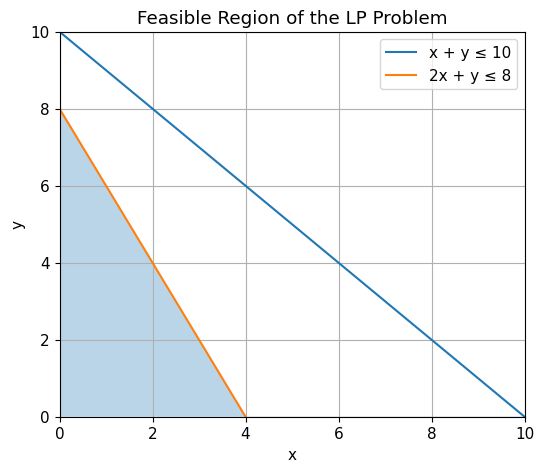

: 

: 

In [ ]:
x = np.linspace(0, 10, 400)

# Constraint lines
y1 = 10 - x          # x + y <= 10
y2 = 8 - 2*x         # 2x + y <= 8

plt.plot(x, y1, label="x + y ≤ 10")
plt.plot(x, y2, label="2x + y ≤ 8")

# Feasible region
plt.fill_between(x, 0, np.minimum(y1, y2), alpha=0.3)

plt.xlim(0,10)
plt.ylim(0,10)
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid()
plt.title("Feasible Region of the LP Problem")
plt.show()

Corner Points (Basic Feasible Solutions)

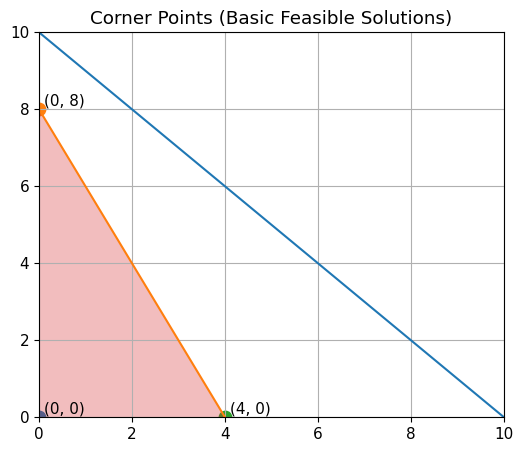

: 

: 

In [ ]:

corner_points = [(0,0), (0,8), (4,0)]

for p in corner_points:
    plt.scatter(p[0], p[1], s=80)
    plt.text(p[0]+0.1, p[1]+0.1, f"{p}")

plt.plot(x, y1)
plt.plot(x, y2)
plt.fill_between(x, 0, np.minimum(y1, y2), alpha=0.3)

plt.xlim(0,10)
plt.ylim(0,10)
plt.title("Corner Points (Basic Feasible Solutions)")
plt.grid()
plt.show()


Objective Function Movement (Simplex Intuition)

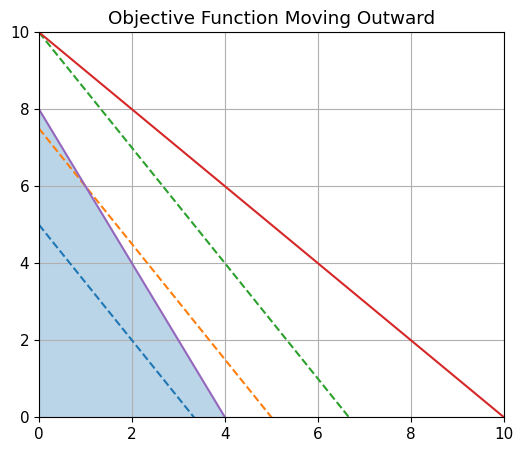

: 

: 

In [ ]:

for z in [10, 15, 20]:
    y_obj = (z - c1*x)/c2
    plt.plot(x, y_obj, linestyle='--')

plt.plot(x, y1)
plt.plot(x, y2)
plt.fill_between(x, 0, np.minimum(y1, y2), alpha=0.3)

plt.xlim(0,10)
plt.ylim(0,10)
plt.title("Objective Function Moving Outward")
plt.grid()
plt.show()

 Simplex Path (Vertex to Vertex Movement)

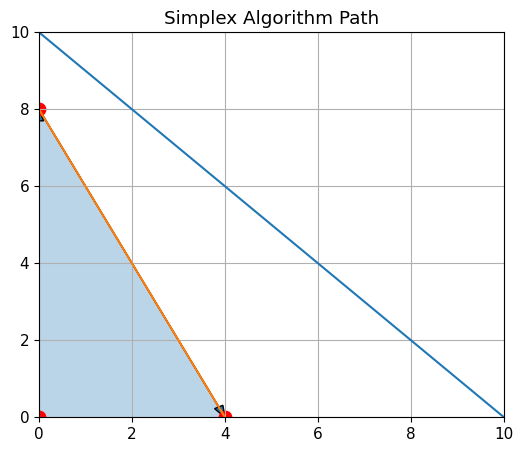

: 

: 

In [ ]:

simplex_path = [(0,0), (0,8), (4,0)]

plt.plot(x, y1)
plt.plot(x, y2)
plt.fill_between(x, 0, np.minimum(y1, y2), alpha=0.3)

for i in range(len(simplex_path)-1):
    x0, y0 = simplex_path[i]
    x1, y1p = simplex_path[i+1]
    plt.arrow(x0, y0, x1-x0, y1p-y0,
              head_width=0.2, length_includes_head=True)

for p in simplex_path:
    plt.scatter(p[0], p[1], color='red', s=80)

plt.xlim(0,10)
plt.ylim(0,10)
plt.title("Simplex Algorithm Path")
plt.grid()
plt.show()


Simplex Tableau (Math ↔ Geometry Bridge)

In [ ]:

tableau = pd.DataFrame(
    [[1, 1, 1, 0, 10],
     [2, 1, 0, 1, 8],
     [-3, -2, 0, 0, 0]],
    columns=["x", "y", "s1", "s2", "RHS"],
    index=["Constraint 1", "Constraint 2", "Objective"]
)

tableau

,x,y,s1,s2,RHS
Constraint 1,1,1,1,0,10
Constraint 2,2,1,0,1,8
Objective,-3,-2,0,0,0


: 

: 

In [ ]:

from scipy.optimize import linprog


# -------------------------------------------------------
# STEP 1: OBJECTIVE FUNCTION
# -------------------------------------------------------
# Minimize: 4x1 + 6x2 + 9x3 + 5x4 + 4x5 + 7x6

c = np.array([-3, -2])

# -------------------------------------------------------
# STEP 3: INEQUALITY CONSTRAINTS (Ax ≤ b)
# -------------------------------------------------------

A_ub = np.array([
    [1, 1],   
    [2, 1],    
      # x + y <= 10   # 2x + y <= 8
])

b_ub = np.array([10, 8])




# -------------------------------------------------------
# STEP 4: VARIABLE BOUNDS
# -------------------------------------------------------

bounds = [(0, None)] * 2



# -------------------------------------------------------
# STEP 5: SOLVE USING OLD SIMPLEX METHOD
# -------------------------------------------------------

start_old = time.perf_counter()

result_old = linprog(
    c,
    A_ub=A_ub,
    b_ub=b_ub,
    bounds=bounds,
    method="simplex"
)

end_old = time.perf_counter()

print("\n=========== OLD SIMPLEX RESULT ===========")
print("Status:", result_old.message)
print("Optimal Value:", -result_old.fun)
print("Solution:", result_old.x)





=========== OLD SIMPLEX RESULT ===========
Status: Optimization terminated successfully.
Optimal Value: 16.0
Solution: [0. 8.]


C:\Users\ravik\AppData\Local\Temp\ipykernel_18084\1829094583.py:40: DeprecationWarning: `method='simplex'` is deprecated and will be removed in SciPy 1.11.0. Please use one of the HiGHS solvers (e.g. `method='highs'`) in new code.
  result_old = linprog(


: 

Solving Using CPLEX (docplex)

In [ ]:

from docplex.mp.model import Model

model = Model(name="LP_Visualization")

x_var = model.continuous_var(name="x", lb=0)
y_var = model.continuous_var(name="y", lb=0)

model.maximize(3*x_var + 2*y_var)

model.add_constraint(x_var + y_var <= 10)
model.add_constraint(2*x_var + y_var <= 8)

solution = model.solve()

solution


docplex.mp.solution.SolveSolution(obj=16,values={y:8})

: 

Plot CPLEX Optimal Solution

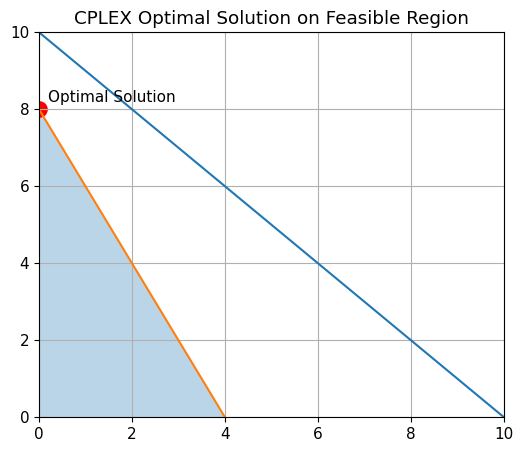

: 

In [ ]:

x_opt = x_var.solution_value
y_opt = y_var.solution_value

plt.plot(x, 10-x)
plt.plot(x, 8-2*x)
plt.fill_between(x, 0, np.minimum(10-x, 8-2*x), alpha=0.3)

plt.scatter(x_opt, y_opt, color='red', s=120)
plt.text(x_opt+0.2, y_opt+0.2, "Optimal Solution")

plt.xlim(0,10)
plt.ylim(0,10)
plt.title("CPLEX Optimal Solution on Feasible Region")
plt.grid()
plt.show()


Now Move to Advance

In [ ]:

# IMPORT LIBRARIES
import numpy as np
from scipy.optimize import linprog
import time


: 

In [ ]:
# -------------------------------------------------------
# STEP 1: OBJECTIVE FUNCTION
# -------------------------------------------------------
# Minimize: 4x1 + 6x2 + 9x3 + 5x4 + 4x5 + 7x6

c = np.array([4, 6, 9, 5, 4, 7])

# -------------------------------------------------------
# STEP 3: INEQUALITY CONSTRAINTS (Ax ≤ b)
# -------------------------------------------------------

A_ub = np.array([
    [1, -2, 1, 0, 0, 0],    # x1 - 2x2 + x3 ≤ 40
    [0, 0, 0, 4, 1, 1],    # 4x4 + x5 + x6 ≤ 30
    [1, 0, 0, -8, 0, 0],   # x1 - 8x4 ≤ 30
    [0, 2, 0, 0, 1, 0],    # 2x2 + x5 ≤ 20
    [0, 0, -1, 0, 0, 9],   # -x3 + 9x6 ≤ 10
    [-1, -1, -1, 0, 0, 0]  # x1 + x2 + x3 ≥ 15
])

b_ub = np.array([40, 30, 30, 20, 10, -15])




# -------------------------------------------------------
# STEP 4: VARIABLE BOUNDS
# -------------------------------------------------------

bounds = [(0, None)] * 6


: 

In [ ]:


# -------------------------------------------------------
# STEP 5: SOLVE USING OLD SIMPLEX METHOD
# -------------------------------------------------------

start_old = time.perf_counter()

result_old = linprog(
    c,
    A_ub=A_ub,
    b_ub=b_ub,
    bounds=bounds,
    method="simplex"
)

end_old = time.perf_counter()

print("\n=========== OLD SIMPLEX RESULT ===========")
print("Status:", result_old.message)
print("Optimal Value:", result_old.fun)
print("Solution:", result_old.x)
print("Time Taken (seconds):", end_old - start_old)




=========== OLD SIMPLEX RESULT ===========
Status: Optimization terminated successfully.
Optimal Value: 60.0
Solution: [15.  0.  0.  0.  0.  0.]
Time Taken (seconds): 0.021401399979367852


C:\Users\ravik\AppData\Local\Temp\ipykernel_18084\3550054584.py:7: DeprecationWarning: `method='simplex'` is deprecated and will be removed in SciPy 1.11.0. Please use one of the HiGHS solvers (e.g. `method='highs'`) in new code.
  result_old = linprog(


: 

# NEW HiGHS SOLVER

In [ ]:

# -------------------------------------------------------
# STEP 6: SOLVE USING NEW HiGHS METHOD
# -------------------------------------------------------

start_new = time.perf_counter()

result_new = linprog(
    c,
    A_ub=A_ub,
    b_ub=b_ub,
    bounds=bounds,
    method="highs"
)

end_new = time.perf_counter()

print("\n=========== NEW HiGHS RESULT ===========")
print("Status:", result_new.message)
print("Optimal Value:", result_new.fun)
print("Solution:", result_new.x)
print("Time Taken (seconds):", end_new - start_new)




=========== NEW HiGHS RESULT ===========
Status: Optimization terminated successfully. (HiGHS Status 7: Optimal)
Optimal Value: 60.0
Solution: [15.  0.  0.  0.  0.  0.]
Time Taken (seconds): 0.06451970001216978


: 

#Exercises

In [ ]:
"""

CURRENT PROBLEM:
--------------
Decision Variables:
x1, x2, x3, x4, x5, x6 ≥ 0

Objective Function (Minimize):
Z= 4x1 + 6x2 + 9x3 + 5x4 + 4x5 + 7x6

Subject to (Constraints):

Inequality constraints:
x1 - 2x2 + x3 ≤ 40,
4x4 + x5 + x6 ≤ 30,
x1 - 8x4 ≤ 30,
2x2 + x5 ≤ 20,
-x3 + 9x6 ≤ 10,
x1 + x2 + x3 ≥ 15.

---------------------------------------------------------
EXERCISE 1: CHANGE A CONSTRAINT
---------------------------------------------------------
Change:
x1 -2*x2 + x3 ≤ 40
to:
x1 + x2 + x3 ≤ 30

Hint:
Modify the corresponding value in b_ub and A_ub..


---------------------------------------------------------
EXERCISE 2: INCREASE DECISION VARIABLES
---------------------------------------------------------
Add two new decision variables x7 and x8 with costs:

x7 → cost = 3
x8 → cost = 6

Hints:
- Extend the objective vector c
- Add zeros for x7 and x8 in every constraint row of A_ub
- Update bounds to include x7 and x8
- Keep all constraints as inequalities (Ax ≤ b)


---------------------------------------------------------
EXERCISE 3: REMOVE ONE INEQUALITY CONSTRAINT
---------------------------------------------------------
Remove the constraint:
2x2 + x5 ≤ 20

Hints:
- Delete the corresponding row from A_ub
- Delete the corresponding value from b_ub
- Re-solve the model and observe how the solution changes



---------------------------------------------------------
EXERCISE 4: CREATE AN INFEASIBLE MODEL
---------------------------------------------------------
Force infeasibility by setting contradictory limits, for example:

x1 + x2 + x3 ≥ 15
x1 + x2 + x3 ≤ 15 


Hints:
- Modify b_ub accordingly
- Run the solver
- Observe the solver status message indicating infeasibility

---------------------------------------------------------
EXERCISE 5: Convert this minimization problem to maximization:
---------------------------------------------------------

 what would you change?
"""


'\n\nCURRENT PROBLEM:\n--------------\nDecision Variables:\nx1, x2, x3, x4, x5, x6 ≥ 0\n\nObjective Function (Minimize):\nZ= 4x1 + 6x2 + 9x3 + 5x4 + 4x5 + 7x6\n\nSubject to (Constraints):\n\nInequality constraints:\nx1 - 2x2 + x3 ≤ 40,\n4x4 + x5 + x6 ≤ 30,\nx1 - 8x4 ≤ 30,\n2x2 + x5 ≤ 20,\n-x3 + 9x6 ≤ 10,\nx1 + x2 + x3 ≥ 15.\n\n---------------------------------------------------------\nEXERCISE 1: CHANGE A CONSTRAINT\n---------------------------------------------------------\nChange:\nx1 -2*x2 + x3 ≤ 40\nto:\nx1 + x2 + x3 ≤ 30\n\nHint:\nModify the corresponding value in b_ub and A_ub..\n\n\n---------------------------------------------------------\nEXERCISE 2: INCREASE DECISION VARIABLES\n---------------------------------------------------------\nAdd two new decision variables x7 and x8 with costs:\n\nx7 → cost = 3\nx8 → cost = 6\n\nHints:\n- Extend the objective vector c\n- Add zeros for x7 and x8 in every constraint row of A_ub\n- Update bounds to include x7 and x8\n- Keep all constra

: 

# Cplex solver

In [ ]:
from docplex.mp.model import Model

# Create model
model = Model(name="LP_using_CPLEX")

# Decision variables
x1 = model.continuous_var(lb=0, name="x1")
x2 = model.continuous_var(lb=0, name="x2")
x3 = model.continuous_var(lb=0, name="x3")
x4 = model.continuous_var(lb=0, name="x4")
x5 = model.continuous_var(lb=0, name="x5")
x6 = model.continuous_var(lb=0, name="x6")

# Objective function (MINIMIZATION)
model.minimize(4*x1 + 6*x2 + 9*x3 + 5*x4 + 4*x5 + 7*x6)

# Constraints (EXACT match to your A_ub, b_ub)
model.add_constraint(x1 - 2*x2 + x3 <= 40)
model.add_constraint(4*x4 + x5 + x6 <= 30)
model.add_constraint(x1 - 8*x4 <= 30)
model.add_constraint(2*x2 + x5 <= 20)
model.add_constraint(-x3 + 9*x6 <= 10)
model.add_constraint(x1 + x2 + x3 >= 15)

# Solve
solution = model.solve(log_output=True)

# Output
if solution:
    print("Optimal Solution Found")
    print("x1 =", x1.solution_value)
    print("x2 =", x2.solution_value)
    print("x3 =", x3.solution_value)
    print("x4 =", x4.solution_value)
    print("x5 =", x5.solution_value)
    print("x6 =", x6.solution_value)
    print("Objective value =", model.objective_value)
else:
    print("No solution found")


Version identifier: 22.1.2.0 | 2024-12-09 | 8bd2200c8
CPXPARAM_Read_DataCheck                          1
Tried aggregator 1 time.
LP Presolve eliminated 3 rows and 2 columns.
Reduced LP has 3 rows, 4 columns, and 8 nonzeros.
Presolve time = 0.00 sec. (0.00 ticks)

Iteration log . . .
Iteration:     1   Dual objective     =            60.000000
Optimal Solution Found
x1 = 15.0
x2 = 0
x3 = 0
x4 = 0
x5 = 0
x6 = 0
Objective value = 60.0


: 